# Laboratorio Integrador #1

En el siguiente laboratorio los estudiantes deben trabajar con un dataset de **alta numerosidad-baja dimensionalidad** y aplicar las técnicas de reducción de dimensionalidad estudiadas en clases, así como la integración de las mismas dentro de un sistema de detección de anomalías. Además, se recomienda que los estudiantes validen los espacios reducidos para contrastar resultados.

Objetivo:
*   Implementar un sistema de detección de anomalías sobre el espacio original de los datos, varios espacios reducidos con las técnicas Isomap e ICA.
*   Analizar los espacios reducidos usando algoritmos clásicos de detección de anomalías (Isolation Forest, Local Outlier Factor, one-class SVM) para la detección de anomalías.

Actividad Evaluativa:
1.   Es un trabajo por equipo.
2.   Implementar y aplicar las dos técnicas de reducción de dimensionalidad (Isomap e ICA) al dataset de trabajo (divir en training and test sets usando un split tradicional: 70:30; 80-20; 50-50 siempre que sea posible) y obtener al menos 4 espacios reducidos (4 por cada método aplicado variando los parámetros) de características. Sugerentemente variar los parámetros de los modelos de reducción de dimensionalidad para generar los espacios reducidos (ej: n_components = 5,10,15,20, 25; neighbors=5,10). Mostrar los gráficos (scatter o tSNE en 2D o 3D) de los espacios reducidos para cada combinación de parámetros (Un subplot tipo grid)
3.   Investigar, implementar y aplicar en el espacio original y los reducidos (del punto 2), al menos uno de los algoritmos de detección de anomalías mencionados (Isolation Forest, Local Outlier Factor, one-class SVM) y medir el desempeño de clasificación usando dos métricas supervisadas (Accuracy, Precision, Recall). Además, construir el plot PR (precission-recall) para cada resultado de clasficación del o los algoritmos seleccionado(s).
4.   Presentar un análisis de resultados de acuerdo a las métricas calculadas y el plot PR (precision-recall) donde se evidencie la comparativa y la selección del esquema ganador (por ejemplo: modelo de reducción + algoritmo de detección de anomalía que maximiza el numero de detección) durante el entrenamiento.
5.   Aplicar el esquema seleccionado como ganador (del punto 4) al conjunto test y calcular las métricas precision y recall para constatar el poder de generalización (resultados de entrenamiento vs test) y escribir sus propias conclusiones.
6.   Subir el cuaderno desarrollado a la carpeta de trabajo en el D2L.

**Nota:** El conjunto test no puede tener más del 90% de las instancias.  

Valor:
*   25 puntos

Penalizaciones:
*   Cualquier error de implementación o concepto, se penalizará con -1 punto (acumulativo).
*   La no realización del punto 2 de la actividad se penalizará con el 50% (10 puntos).
*   La no realización del punto 3 de la actividad se penalizará con el 20% (4 puntos).
*   La no realización del punto 4 de la actividad se penalizará con el 20% (4 puntos).
*   La no realización del punto 5 de la actividad se penalizará con el 10% (2 puntos).
*   La no realización del punto 6 de la actividad se penalizará con el 100% (25 puntos).



# *Setup*
Overall libraries for data handling, visualization, preparation, and evaluation

In [ ]:
# Import libraries
'''Main'''
import numpy as np
import pandas as pd
import os, time
import io
import pickle, gzip

'''Data Viz'''
import matplotlib.pyplot as plt
import seaborn as sns
color = sns.color_palette()
import matplotlib as mpl

%matplotlib inline

'''Data Prep and Model Evaluation'''
from sklearn import preprocessing as pp
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.decomposition import FastICA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import Isomap

In [2]:
# Variables globales

TEST_SIZE = 0.3
RANDOM_STATE = 42

In [3]:

# Funciones de utilidad

'''
Función para preparar datos
'''
def prepare_data(df):
    X = df.drop(['Class'], axis=1)
    y = df['Class']

    print(f"Datos preparados: {X.shape}")
    print(f"Features seleccionadas: {list(X.columns)}")
    print(f"Distribución de clases: {y.value_counts().to_string()}")

    return X, y

# View scatterplot
def scatterPlot(xDF, yDF, algoName):
    tempDF = pd.DataFrame(data=xDF.loc[:,0:1], index=xDF.index)
    tempDF = pd.concat((tempDF,yDF), axis=1, join="inner")
    tempDF.columns = ["First Vector", "Second Vector", "Label"]
    sns.lmplot(x="First Vector", y="Second Vector", hue="Label", \
               data=tempDF, fit_reg=False)
    ax = plt.gca()
    ax.set_title("Separation of Observations using "+algoName)

# Load and Explore data

In [4]:
# Load datasets
file_path = 'credit_card.csv'
data = pd.read_csv(file_path)
# Preview data
data.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
# Describe data
data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [6]:
# Count total fraud
print("Number of fraudulent transactions:", data['Class'].sum())

Number of fraudulent transactions: 492


# Punto 2




## Implementar los métodos de reducción de dimensionalidad y generar 4 espacios reducidos (derivados de la variación de parámetros) por cada uno:



## Preprocesamiento

In [7]:

# Split to train and test and scale features

# 1. Preparar datos
X, y = prepare_data(data)

# 2. Dividir en train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

# Escalar datos 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Datos preparados: (284807, 30)
Features seleccionadas: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']
Distribución de clases: Class
0    284315
1       492
Train: (199364, 30)
Test : (85443, 30)


## Isomap

In [ ]:
# Convertir nuevamente a DataFrame

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

print("Datos escalados correctamente")

In [ ]:
# ============================================================
# 5. Muestreo para ISOMAP
# Mantener todos los fraudes y reducir normales
# ============================================================

N_NORMAL_SAMPLE = 20000

# Fraudes: se mantienen todos
X_frauds = X_train_scaled[y_train == 1]
y_frauds = y_train[y_train == 1]

# Normales: se reducen por muestreo
X_normals = X_train_scaled[y_train == 0]
y_normals = y_train[y_train == 0]
n_sample = min(N_NORMAL_SAMPLE, X_normals.shape[0])
X_normals_sample = X_normals.sample(
    n=n_sample,
    random_state=RANDOM_STATE
)

y_normals_sample = y_normals.loc[X_normals_sample.index]

# Unir muestra normal + todos los fraudes
X_iso_sample = pd.concat([X_normals_sample, X_frauds], axis=0)
y_iso_sample = pd.concat([y_normals_sample, y_frauds], axis=0)

# Mezclar filas
X_iso_sample = X_iso_sample.sample(
    frac=1,
    random_state=RANDOM_STATE
)

y_iso_sample = y_iso_sample.loc[X_iso_sample.index]

print("Dataset reducido para ISOMAP:", X_iso_sample.shape)
print(y_iso_sample.value_counts())

In [ ]:
# ============================================================
# 6. Definir parámetros a tunear
# ============================================================

neighbors_list = [2, 3, 5]
components_list = [4, 5]
isomap_results = {}

In [ ]:
# ============================================================
# 7. Ejecutar ISOMAP en bucle
# ============================================================

for n_neighbors in neighbors_list:
    for n_components in components_list:

        name = f"ISOMAP_k{n_neighbors}_comp{n_components}"
        print(f"Ejecutando {name}...")

        isomap = Isomap(
            n_neighbors=n_neighbors,
            n_components=n_components,
            n_jobs=-1
        )

        X_iso = isomap.fit_transform(X_iso_sample)
        X_iso = pd.DataFrame(
            X_iso,
            columns=[f"ISO_{i+1}" for i in range(n_components)],
            index=X_iso_sample.index
        )

        isomap_results[name] = X_iso

        print(f"{name} terminado: {X_iso.shape}")

## ICA

In [ ]:
# Parámetros a variar para generar 4 espacios reducidos
n_components_list = [10, 15, 20, 25]

# Parametros
ALGORITHM = "parallel"
WHITEN = "unit-variance"
MAX_ITER = 100

# Diccionario de almacenamiento (modelos y datos transformados)
ica_models = {}
X_train_ica = {}
X_test_ica = {}

# Entrenar ICA con diferentes valores de n_components
for n_comp in n_components_list:
    print(f"Entrenando ICA con n_components={n_comp}...")

    # ICA    
    ica = FastICA(n_components=n_comp, algorithm=ALGORITHM, whiten=WHITEN, random_state=RANDOM_STATE, max_iter=MAX_ITER)
    
    X_train_ica[n_comp] = ica.fit_transform(X_train_scaled)
    X_test_ica[n_comp] = ica.transform(X_test_scaled)
    
    # Guardar modelo
    ica_models[n_comp] = ica
    
    print(f"  Espacio reducido entrenamiento: {X_train_ica[n_comp].shape}")
    print(f"  Espacio reducido test: {X_test_ica[n_comp].shape}\n")


Entrenando ICA con n_components=10...
  Espacio reducido entrenamiento: (199364, 10)
  Espacio reducido test: (85443, 10)

Entrenando ICA con n_components=15...
  Espacio reducido entrenamiento: (199364, 15)
  Espacio reducido test: (85443, 15)

Entrenando ICA con n_components=20...
  Espacio reducido entrenamiento: (199364, 20)
  Espacio reducido test: (85443, 20)

Entrenando ICA con n_components=25...
  Espacio reducido entrenamiento: (199364, 25)
  Espacio reducido test: (85443, 25)



ICA con n_components=10...


ICA con n_components=10...


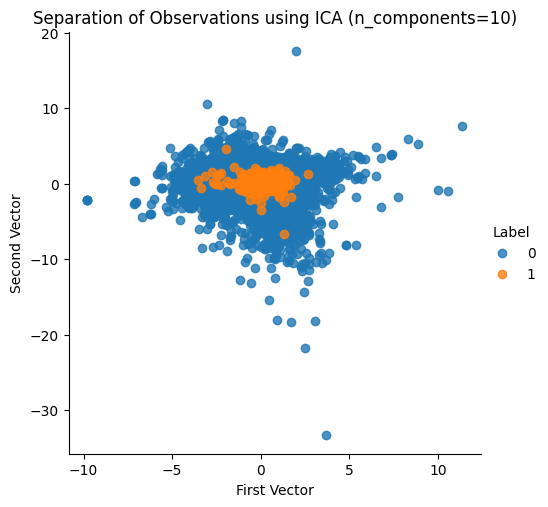

ICA con n_components=10...


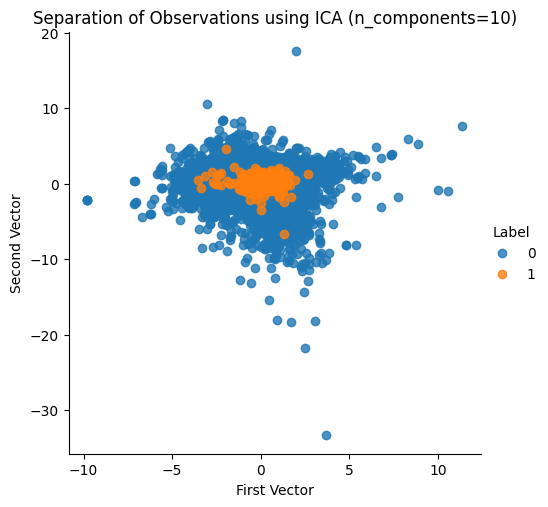

ICA con n_components=15...


ICA con n_components=10...


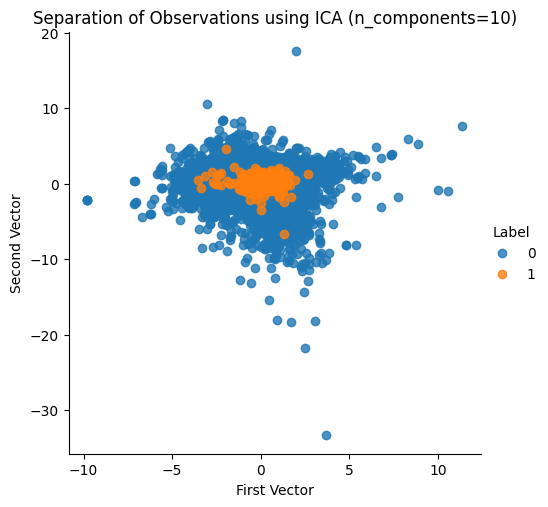

ICA con n_components=15...


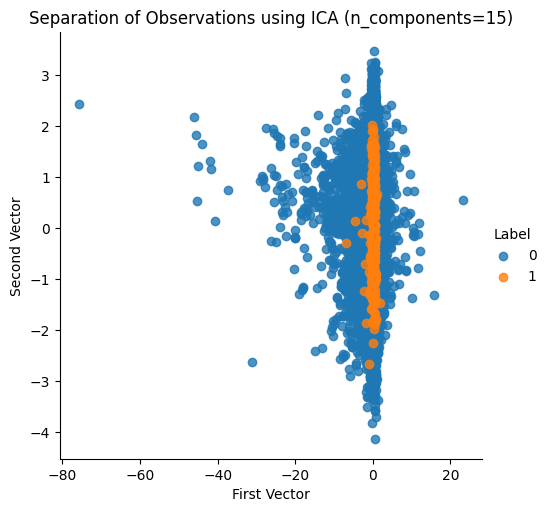

ICA con n_components=10...


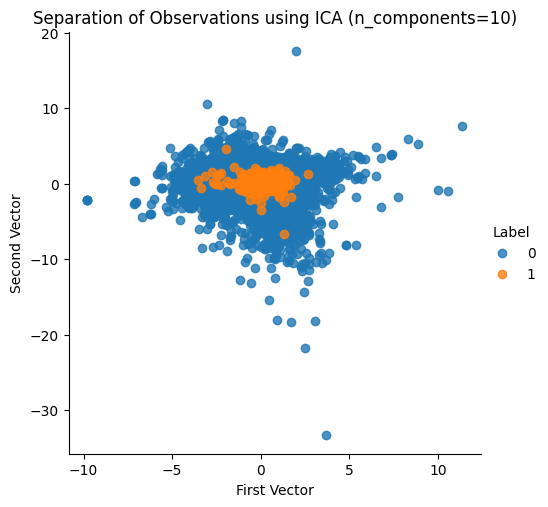

ICA con n_components=15...


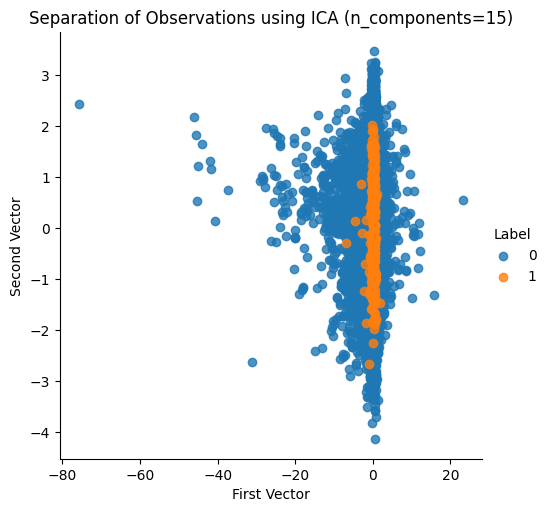

ICA con n_components=20...


ICA con n_components=10...


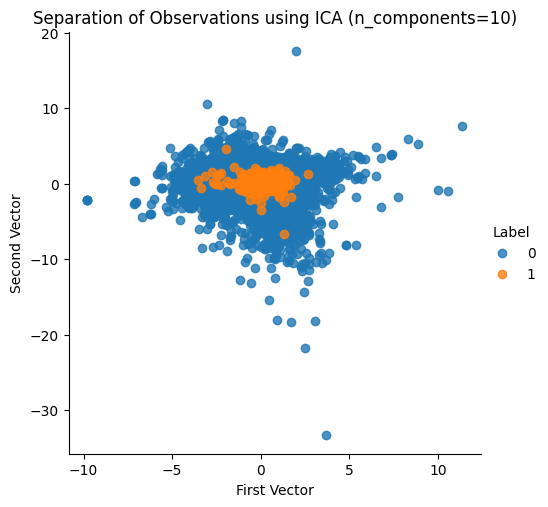

ICA con n_components=15...


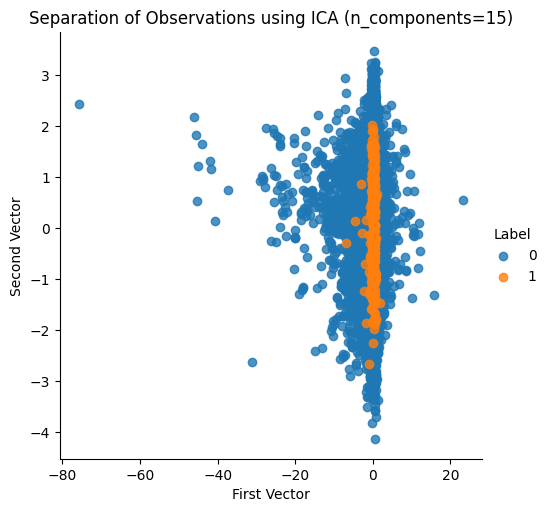

ICA con n_components=20...


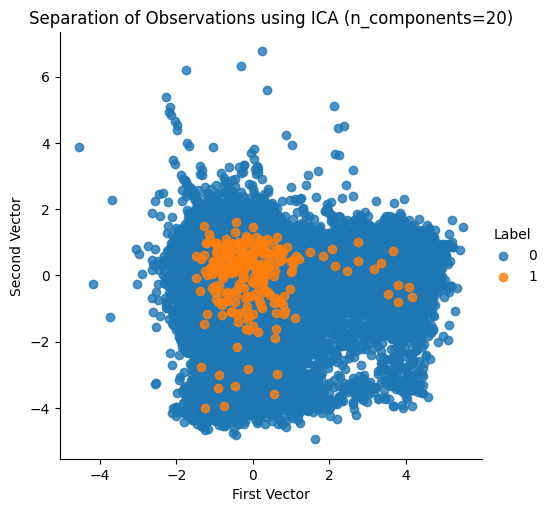

ICA con n_components=10...


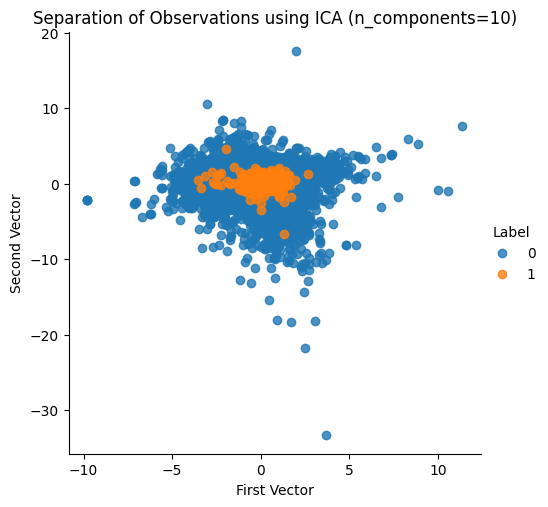

ICA con n_components=15...


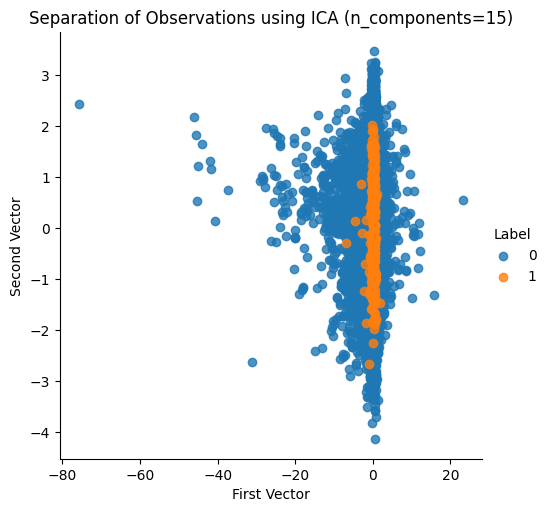

ICA con n_components=20...


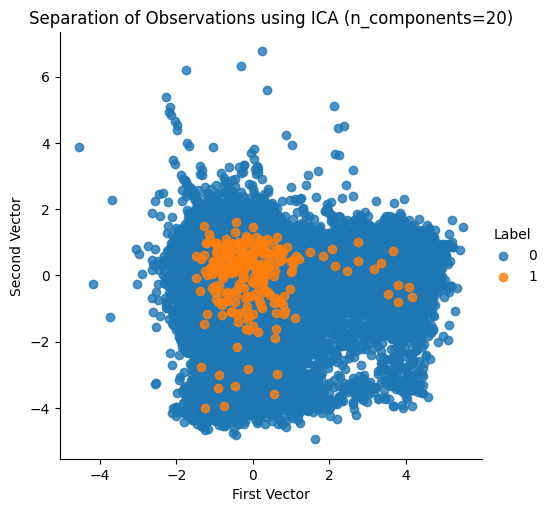

ICA con n_components=25...


ICA con n_components=10...


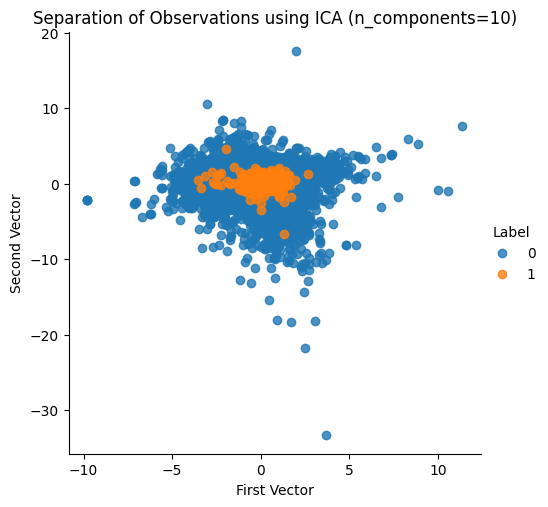

ICA con n_components=15...


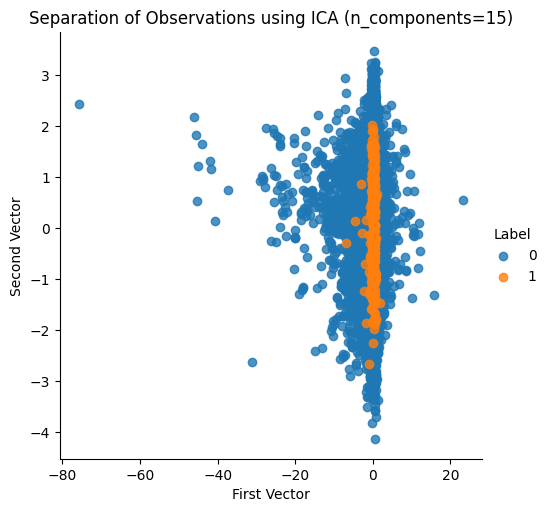

ICA con n_components=20...


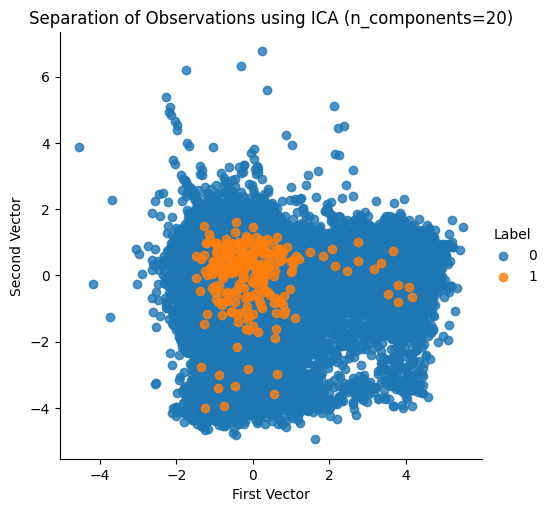

ICA con n_components=25...


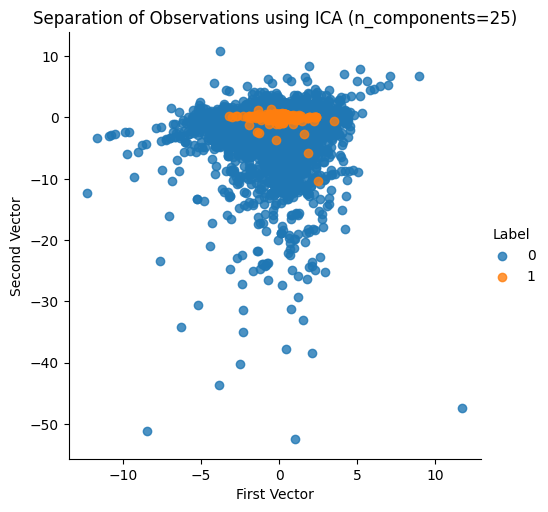

In [32]:
# Visualizacion
for n_comp in n_components_list:
    print(f"ICA con n_components={n_comp}...")
    scatterPlot(pd.DataFrame(X_train_ica[n_comp]), y_train, f"ICA (n_components={n_comp})")
    plt.show()

# Punto 3



## Investigar, implementar y aplicar el método de detección de anomalías en el espacio original y reducidos:



In [29]:
from sklearn.ensemble import IsolationForest

# Parámetros del Isolation Forest

In [30]:
from sklearn.neighbors import LocalOutlierFactor

# Parámetros del Local Outlier Factor

In [31]:
from sklearn.svm import OneClassSVM

# Parámetros del One-Class SVM

# Punto 4


## Análisis de resultados en los espacios original y reducidos del conjunto de etrenamiento

# Punto 5

## Análisis de resultados de la aplicación del mejor esquema seleccionado en el entrenamiento sobre el conjunto de test 

## Conclusiones